# MISMIP+ marine ice sheet: two-layer composite rheology

Diagnostic momentum solve on the MISMIP+ benchmark geometry (Asay-Davis et al. 2016) with the multilayer dual model and a composite, depth-varying rheology.

| Layer | Fraction | $n$ | $A$ (MPa$^{-n}$ yr$^{-1}$) | Mechanism |
|-------|----------|-----|----------------------------|-----------|
| Base  | 15%      | 4.0 | 46    | dislocation creep, temperate |
| Top   | 85%      | 1.8 | 0.24  | grain-boundary sliding, $-20$ degC |

## Why this notebook uses the variational form

This solve is assembled from the **variational (weak-form) residuals** in `multilayer.model.variational`, not the minimization (action) form that icepack uses. In this example, the marine ice sheet has a shelf where the effective pressure $N\to0$, so the basal drag must vanish there *exactly*. In the variational form the basal stress obeys the regularised-Coulomb residual

$$\tau + \beta^2\Big(\tfrac{|u|}{|u|+u_0}\Big)^{1/m}\hat u = 0,\qquad \beta^2 = C\,N,$$

so $\beta^2\to0$ on the shelf gives $\tau\to0$ — **true free slip, with no friction floor**. The minimization form instead needs the *compliance* $K=1/\beta^2$, which diverges as $N\to0$ and forces an unphysical floor on the shelf. 

## Robustness

The flow-law and friction Jacobian blocks scale like $|\text{stress}|^{p-1}$ and vanish at zero stress for $p>1$, so we ramp the flow exponent $n$ **and** the sliding exponent $m$ from $1$ to their targets. The regularised-Coulomb basal residual has an identity stress-block, so no friction floor or extra regularisation is needed. (For the minimization form, or for prognostic runs where $h\to0$, `composite_viscous_power` adds an $n=1$ regulariser.)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import firedrake
from firedrake import (
    Constant, Function, SpatialCoordinate, RectangleMesh,
    exp, sqrt, inner, dx, max_value, as_vector,
    DirichletBC, NonlinearVariationalProblem, NonlinearVariationalSolver,
)
from icepack2.constants import (
    ice_density as rho_I, water_density as rho_W, gravity as g,
)
from multilayer.model import variational, utilities

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [3]:
# Direct solve (preonly + LU); robustness comes from the n & m continuation.
# snes_divergence_tolerance=-1 tolerates a transient uphill Newton step.
sparams = {
    "snes_type": "newtonls",
    "snes_max_it": 200,
    "snes_linesearch_type": "bt",
    "snes_divergence_tolerance": -1,
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}
fcp = {"form_compiler_parameters": {"quadrature_degree": 6}}

# Boundary ids for RectangleMesh: 1 = divide (x=0), 2 = terminus (x=Lx),
# 3, 4 = side walls (y=0, y=Ly).
DIVIDE_ID, TERMINUS_ID, WALL_IDS = 1, 2, (3, 4)

## Domain and bed topography

The MISMIP+ domain is $640\times80$ km. The bed is a sixth-order polynomial in
$x$ with a Gaussian side-channel in $y$, floored at $-720$ m.

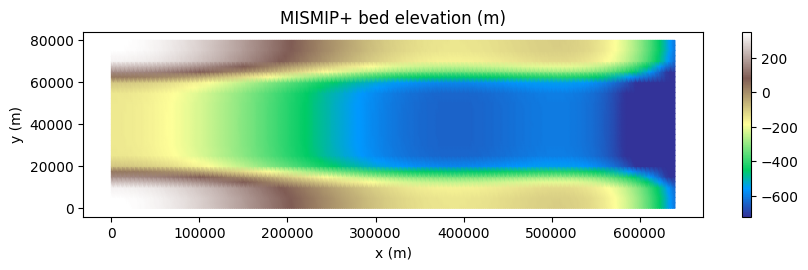

In [4]:
Lx, Ly = 640e3, 80e3
nx, ny = 128, 16
mesh = RectangleMesh(nx, ny, Lx, Ly)
x, y = SpatialCoordinate(mesh)
Q = firedrake.FunctionSpace(mesh, "CG", 1)

x_c = Constant(300e3)
X = x / x_c
B_0, B_2, B_4, B_6 = -150.0, -728.8, 343.91, -50.57
B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6

f_c, d_c, w_c = 4e3, 500.0, 24e3
B_y = d_c * (
    1 / (1 + exp(-2 * (y - Ly / 2 - w_c) / f_c))
    + 1 / (1 + exp(+2 * (y - Ly / 2 + w_c) / f_c))
)
bed = Function(Q, name="bed").interpolate(max_value(B_x + B_y, Constant(-720.0)))

fig, ax = plt.subplots(figsize=(10, 2.4))
tpc = firedrake.tripcolor(bed, axes=ax, cmap="terrain")
ax.set_title("MISMIP+ bed elevation (m)")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
fig.colorbar(tpc, ax=ax);

## Initial geometry

A smooth grounded profile thinning seaward into a floating shelf. The surface
follows flotation and the effective pressure $N=\rho_I g\,(H-H_f)$ (with
$H_f=-b\,\rho_W/\rho_I$) is clamped at zero, so it vanishes on floating ice and
the basal drag $\beta^2 = C N$ vanishes with it.

(This prescribed thickness is an initial condition for the *diagnostic* solve;
it is **not** the MISMIP+ steady state. The steady geometry is reached by the
prognostic spin-up in `mismip_plus_spinup.py` — see the closing note.)

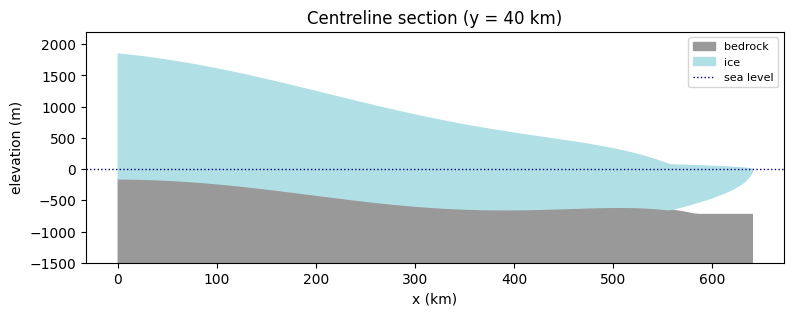

In [5]:
R_FLOT = float(rho_I / rho_W)
H_div, H_min = 2000.0, 50.0
H = Function(Q, name="thickness").interpolate(
    max_value(Constant(H_min), Constant(H_div) * max_value(Constant(0.0), 1 - x / Lx) ** 0.5)
)
surface = Function(Q, name="surface").interpolate(
    max_value(bed + H, (1 - Constant(R_FLOT)) * H)
)
H_f = max_value(Constant(0.0), -bed) * Constant(rho_W / rho_I)
N = Function(Q, name="effective_pressure").interpolate(
    max_value(rho_I * g * (H - H_f), Constant(0.0))
)

# Centreline section
xs = np.linspace(0.0, Lx, 201)
b_line = np.array([bed.at([xi, Ly / 2]) for xi in xs])
s_line = np.array([surface.at([xi, Ly / 2]) for xi in xs])
h_line = np.array([H.at([xi, Ly / 2]) for xi in xs])
base_line = s_line - h_line
haf_line = h_line - np.maximum(0.0, -b_line) / R_FLOT
gl = xs[np.where((haf_line[:-1] > 0) & (haf_line[1:] <= 0))[0]]
x_gl = gl[0] if len(gl) else None

fig, ax = plt.subplots(figsize=(9, 3))
ax.fill_between(xs / 1e3, b_line, -1500, color="0.6", label="bedrock")
ax.fill_between(xs / 1e3, base_line, s_line, color="powderblue", label="ice")
ax.axhline(0.0, color="navy", ls=":", lw=1, label="sea level")
ax.set_xlabel("x (km)"); ax.set_ylabel("elevation (m)"); ax.set_ylim(-1500, 2200)
ax.set_title("Centreline section (y = 40 km)"); ax.legend(fontsize=8);

## Rheology and sliding parameters

Per-layer exponents and rate factors are `Constant`s so they can be ramped. The
warm start uses the effective Glen $n=3$, $A=100$ rheology; the two-layer
continuation relaxes to the composite $n=4$ / $n=1.8$ targets. Basal sliding is
regularised Coulomb with $\beta^2 = C N$ (no floor): drag tapers to zero toward
the grounding line and is identically zero on the floating shelf.

In [6]:
LAYER_FRACTIONS = [0.15, 0.85]      # bottom, top
LAYER_EXPONENTS = [4.0, 1.8]
LAYER_PREFACTORS = [46.0, 0.24]     # MPa^-n yr^-1
NUM_LAYERS = 2

# Depth-averaged ("effective Glen") rheology for the warm start.
N_AVG, A_AVG = 3.0, 100.0

# Regularised-Coulomb basal sliding: beta^2 = C * N (NO floor).
COULOMB_C, U_0, SLIDING_M = 0.5, 300.0, 3.0
beta2 = Constant(COULOMB_C) * N      # -> 0 on floating ice => exact free slip

## Depth-averaged warm start

A single-layer (SSA-like) diagnostic solve with one effective rate factor
provides the initial velocity for the two-layer model. We assemble the
variational residual (flow law + momentum balance + regularised-Coulomb friction
+ calving terminus) and ramp the flow exponent $n$ **and** sliding exponent $m$
from $1$ to $3$.

In [7]:
Z1 = utilities.create_function_space(mesh, 1)
z1 = Function(Z1)
z1.sub(0).interpolate(as_vector([Constant(10.0), Constant(0.0)]))
f1 = utilities.split_fields(firedrake.split(z1), 1)[0]

n1 = Constant(1.0)
m1 = Constant(1.0)

F1 = (
    variational.flow_law(
        velocity=f1["velocity"], membrane_stress=f1["membrane_stress"],
        thickness=H, flow_law_coefficient=Constant(A_AVG), flow_law_exponent=n1,
    )
    + variational.momentum_balance(
        velocity=f1["velocity"], membrane_stress=f1["membrane_stress"],
        thickness=H, surface=surface, basal_stress=f1["interlayer_stress"],
    )
    + variational.schoof_friction(
        basal_stress=f1["interlayer_stress"], velocity=f1["velocity"],
        friction_coefficient=beta2, transition_speed=Constant(U_0), sliding_exponent=m1,
    )
    + variational.calving_terminus(
        velocity=f1["velocity"], thickness=H, surface=surface,
        outflow_ids=(TERMINUS_ID,), layer_fraction=Constant(1.0),
    )
)
bcs1 = [
    DirichletBC(Z1.sub(0).sub(0), 0, (DIVIDE_ID,)),
    DirichletBC(Z1.sub(0).sub(1), 0, WALL_IDS),
]
solver1 = NonlinearVariationalSolver(
    NonlinearVariationalProblem(F1, z1, bcs1, **fcp), solver_parameters=sparams
)

for lam in np.linspace(0.0, 1.0, 12):
    n1.assign((1 - lam) + lam * N_AVG)
    m1.assign((1 - lam) + lam * SLIDING_M)
    solver1.solve()

print(f"warm start: max depth-averaged speed = {np.max(np.abs(z1.subfunctions[0].dat.data_ro[:, 0])):.1f} m/yr")

warm start: max depth-averaged speed = 3661.1 m/yr


## Two-layer solve

We assemble the multilayer variational residual (per-layer flow law, momentum
balance and calving terminus; regularised-Coulomb basal friction; interlayer
shear), seed every layer's velocity from the warm start, and run a continuation
that relaxes the per-layer exponents from $n=m=1$ to the $n=4$ / $n=1.8$ targets
(splitting $A$ in log-space) while ramping the sliding exponent to $3$.

In [8]:
# Per-layer thicknesses as INDEPENDENT fields. In the spin-up each layer is
# advected by its own velocity, so the fractions evolve freely; the total is
# H = h_0 + h_1 (initially h_l = f_l * H).
h_layers = [Function(Q, name=f"h_layer{l}").interpolate(Constant(LAYER_FRACTIONS[l]) * H)
            for l in range(NUM_LAYERS)]
n_consts = [Constant(1.0) for _ in range(NUM_LAYERS)]
A_consts = [Constant(A_AVG) for _ in range(NUM_LAYERS)]
m_const = Constant(1.0)

Z = utilities.create_function_space(mesh, NUM_LAYERS)
z = Function(Z)
for l in range(NUM_LAYERS):
    z.sub(3 * l).assign(z1.subfunctions[0])       # velocity
    z.sub(3 * l + 1).assign(z1.subfunctions[1])   # membrane stress
z.sub(2).assign(z1.subfunctions[2])               # bottom-layer basal stress
fields = utilities.split_fields(firedrake.split(z), NUM_LAYERS)

forms = []
for l in range(NUM_LAYERS):
    h_l, fl = h_layers[l], fields[l]
    S_above = fields[l + 1]["interlayer_stress"] if l < NUM_LAYERS - 1 else None
    forms.append(variational.flow_law(
        velocity=fl["velocity"], membrane_stress=fl["membrane_stress"],
        thickness=h_l, flow_law_coefficient=A_consts[l], flow_law_exponent=n_consts[l],
    ))
    forms.append(variational.momentum_balance(
        velocity=fl["velocity"], membrane_stress=fl["membrane_stress"],
        thickness=h_l, surface=surface,
        basal_stress=fl["interlayer_stress"] if l == 0 else None,
        stress_above=S_above,
        stress_below=fl["interlayer_stress"] if l > 0 else None,
    ))
    forms.append(variational.calving_terminus(
        velocity=fl["velocity"], thickness=H, surface=surface,
        outflow_ids=(TERMINUS_ID,), layer_fraction=h_l / H,
    ))

forms.append(variational.schoof_friction(
    basal_stress=fields[0]["interlayer_stress"], velocity=fields[0]["velocity"],
    friction_coefficient=beta2, transition_speed=Constant(U_0), sliding_exponent=m_const,
))
for l in range(1, NUM_LAYERS):
    forms.append(variational.interlayer_stress_law(
        interlayer_stress=fields[l]["interlayer_stress"],
        velocity_above=fields[l]["velocity"], velocity_below=fields[l - 1]["velocity"],
        thickness_above=h_layers[l], thickness_below=h_layers[l - 1],
        flow_law_coefficient=A_consts[l - 1], flow_law_exponent=n_consts[l - 1],
    ))

F = sum(forms)
bcs = []
for l in range(NUM_LAYERS):
    bcs.append(DirichletBC(Z.sub(3 * l).sub(0), 0, (DIVIDE_ID,)))
    bcs.append(DirichletBC(Z.sub(3 * l).sub(1), 0, WALL_IDS))

solver = NonlinearVariationalSolver(
    NonlinearVariationalProblem(F, z, bcs, **fcp), solver_parameters=sparams
)

lambdas = np.concatenate([np.linspace(0.0, 0.7, 9), np.linspace(0.7, 1.0, 8)[1:]])
for lam in lambdas:
    for l in range(NUM_LAYERS):
        n_consts[l].assign((1 - lam) * 1.0 + lam * LAYER_EXPONENTS[l])
        A_consts[l].assign(np.exp((1 - lam) * np.log(A_AVG) + lam * np.log(LAYER_PREFACTORS[l])))
    m_const.assign((1 - lam) * 1.0 + lam * SLIDING_M)
    solver.solve()
print("two-layer solve complete")

two-layer solve complete


## The solution

Surface (top, $n=1.8$) and basal (bottom, $n=4$ temperate) speeds along the
centreline; their difference is the vertical shear the soft temperate base
concentrates. We also print the basal drag $|\tau_b|$ to confirm it tapers to
zero at the grounding line and is **identically zero on the floating shelf**.

MISMIP+ is strongly sliding-dominated, so the column moves nearly as a plug and
the shear is a small fraction of the speed. (Note the grounded ice is slow here:
the prescribed thickness is not the steady state, so this diagnostic field is not
a steady solution — run the spin-up for that.)

  basal drag along the centreline:
    x =   150 km (grounded):  |tau_b| =   61.302 kPa
    x =   400 km (grounded):  |tau_b| =   26.842 kPa
    x =   540 km (near GL ):  |tau_b| =   37.186 kPa
    x =   600 km (SHELF   ):  |tau_b| =    0.000 kPa
    x =   635 km (SHELF   ):  |tau_b| =    0.000 kPa


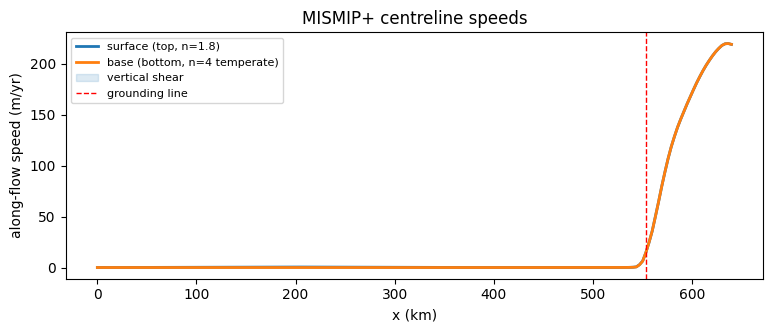

In [9]:
u_bot = z.subfunctions[0]
u_top = z.subfunctions[3]
tau_b = z.subfunctions[2]                       # bottom-layer basal stress
s_top = np.array([u_top.at([xi, Ly / 2])[0] for xi in xs])
s_bot = np.array([u_bot.at([xi, Ly / 2])[0] for xi in xs])

print("  basal drag along the centreline:")
for xq, lbl in [(150e3, "grounded"), (400e3, "grounded"),
                (540e3, "near GL "), (600e3, "SHELF   "), (635e3, "SHELF   ")]:
    tb = float(np.hypot(*tau_b.at([xq, Ly / 2]))) * 1e3   # kPa
    print(f"    x = {xq/1e3:5.0f} km ({lbl}):  |tau_b| = {tb:8.3f} kPa")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(xs / 1e3, s_top, "C0-", lw=2, label="surface (top, n=1.8)")
ax.plot(xs / 1e3, s_bot, "C1-", lw=2, label="base (bottom, n=4 temperate)")
if x_gl is not None:
    ax.axvline(x_gl / 1e3, color="red", ls="--", lw=1, label="grounding line")
ax.set_xlabel("x (km)"); ax.set_ylabel("along-flow speed (m/yr)")
ax.set_title("MISMIP+ centreline speeds"); ax.legend(fontsize=8);

## Prognostic spin-up

We drive the diagnostic forward in time. Each step updates the surface and
effective pressure from the current total thickness $H = h_1 + h_2$, re-solves
the two-layer momentum balance (warm-started), and advances **each layer's
thickness by its own velocity**:

$$\partial_t h_\ell + \nabla\cdot(h_\ell\,u_\ell) = a_\ell,\qquad a_\ell = f_\ell\,a,$$

(DG-upwind, $h_\ell\ge0$ enforced by a variational-inequality solve). We use
$a = 0.05$ m/yr, **reduced from the MISMIP+ value of $0.3$**. Less accumulation
means thinner ice — the grounding line retreats and the shelf grows — and,
crucially, $a = 0.05$ makes the accumulation input ($\approx 2.6$ km$^3$/yr over
the domain) roughly **balance the terminus outflow**, so the total volume reaches
equilibrium ($dV/dt \to 0$) instead of drifting. The accumulation is split
between layers in proportion to the target fractions $f = [0.15, 0.85]$
($a_1 = 0.0075$, $a_2 = 0.0425$ m/yr), but because the two layers are transported
**independently** the thickness fractions $h_\ell/H$ **evolve freely** rather
than staying locked at 15/85. In MISMIP+ the column is nearly plug flow
($u_1\approx u_2$) so the drift is small; it grows where the vertical shear does.

In [10]:
from firedrake import FunctionSpace, FiniteElement, BrokenElement, FacetNormal, ds
import irksome
from icepack2.model import mass_balance

ACCUM = 0.05                                  # m/yr column SMB (reduced from MISMIP+'s
                                              # 0.3 -> thinner ice, GL retreats, larger
                                              # shelf; ~balances terminus outflow, so the
                                              # volume reaches equilibrium, dV/dt -> 0)
a_layer = [LAYER_FRACTIONS[l] * ACCUM for l in range(NUM_LAYERS)]
print("accumulation per layer (proportional to target thickness fractions):")
for l, lbl in enumerate(("bottom", "top")):
    print(f"    {lbl:6s} ({LAYER_FRACTIONS[l]*100:.0f}%): {a_layer[l]:.3f} m/yr")

# Mass-budget accounting: at equilibrium the terminus outflow matches this input.
nu = FacetNormal(mesh)
accum_km3 = ACCUM * firedrake.assemble(Constant(1.0) * dx(mesh)) / 1e9   # km^3/yr over domain
def terminus_outflow():
    return sum(firedrake.assemble(h_layers[l] * max_value(0.0, inner(z.subfunctions[3 * l], nu)) * ds)
               for l in range(NUM_LAYERS)) / 1e9                   # km^3/yr (u.n>0 boundary flux)
print(f"  total accumulation input = {accum_km3:.3f} km^3/yr "
      f"(volume equilibrium = terminus outflow matches this)")

V = z.subfunctions[0].function_space()
dg1 = BrokenElement(FiniteElement("Bernstein", "triangle", 1))
Q_dg = FunctionSpace(mesh, dg1)

# One continuity equation PER LAYER, each advected by that layer's own velocity.
h_dg = [Function(Q_dg, name=f"h{l}_dg").project(h_layers[l]) for l in range(NUM_LAYERS)]
u_layer = [Function(V, name=f"u{l}") for l in range(NUM_LAYERS)]

t = Constant(0.0); dt = Constant(2.0)
tparams = {
    "solver_parameters": {"snes_type": "vinewtonrsls", "snes_max_it": 100,
                          "ksp_type": "gmres", "pc_type": "lu",
                          "pc_factor_mat_solver_type": "mumps"},
    "stage_type": "value", "basis_type": "Bernstein",
}
steppers = []
for l in range(NUM_LAYERS):
    F_l = mass_balance(thickness=h_dg[l], velocity=u_layer[l], accumulation=Constant(a_layer[l]))
    bounds = ("stage", Function(Q_dg).assign(0.0), Function(Q_dg).assign(1.0e4))
    steppers.append(irksome.TimeStepper(
        F_l, irksome.BackwardEuler(), t, dt, h_dg[l], bounds=bounds, **tparams))

accumulation per layer (proportional to target thickness fractions):
    bottom (15%): 0.007 m/yr
    top    (85%): 0.043 m/yr
  total accumulation input = 2.560 km^3/yr (volume equilibrium = terminus outflow matches this)


In [11]:
def grounding_line():
    haf = Function(Q).interpolate(H - max_value(Constant(0.0), -bed) * Constant(rho_W / rho_I))
    v = np.array([haf.at([xi, Ly / 2]) for xi in xs])
    fl = np.where((v[:-1] > 0) & (v[1:] <= 0))[0]
    if not len(fl):
        return float("nan")
    i = fl[0]                                   # sub-grid: linear haf=0 crossing
    frac = v[i] / (v[i] - v[i + 1])
    return (xs[i] + frac * (xs[i + 1] - xs[i])) / 1e3

SPINUP_YEARS = 800.0                          # volume reaches equilibrium (outflow ~ accum,
                                              # dV/dt -> 0) by ~600-700 yr; GL near 520 km
nsteps = int(SPINUP_YEARS / float(dt))
hist = []
for step in range(nsteps + 1):
    H.interpolate(h_layers[0] + h_layers[1])                    # 1. total thickness
    surface.interpolate(max_value(bed + H, (1 - Constant(R_FLOT)) * H))
    N.interpolate(max_value(
        rho_I * g * (H - max_value(Constant(0.0), -bed) * Constant(rho_W / rho_I)), Constant(0.0)))
    solver.solve()                                             # 2. momentum (warm-started)
    for l in range(NUM_LAYERS):
        u_layer[l].assign(z.subfunctions[3 * l])               # 3. per-layer velocities
    vol = firedrake.assemble(H * dx) / 1e12
    hist.append((step * float(dt), grounding_line(),
                 float(np.max(np.abs(z.subfunctions[0].dat.data_ro[:, 0]))), vol))
    if step % 100 == 0:
        print(f"  t = {step*float(dt):5.0f} yr:  GL = {hist[-1][1]:6.1f} km,  "
              f"V = {hist[-1][3]:5.2f} (1e3 km3),  outflow {terminus_outflow():4.2f} / "
              f"accum {accum_km3:4.2f} km3/yr", flush=True)
    if step < nsteps:
        for stp in steppers:
            stp.advance()                                      # 4. advance each layer
        for l in range(NUM_LAYERS):
            h_layers[l].project(h_dg[l])
        t.assign(float(t) + float(dt))
hist = np.array(hist)
print(f"spin-up complete: {SPINUP_YEARS:.0f} yr | grounding line "
      f"{hist[0,1]:.0f} -> {hist[-1,1]:.0f} km | volume "
      f"{hist[0,3]:.2f} -> {hist[-1,3]:.2f} (1e3 km^3)")
print(f"mass budget: terminus outflow {terminus_outflow():.2f} km^3/yr  vs  "
      f"accumulation {accum_km3:.2f} km^3/yr   (close => volume in equilibrium)")

  t =     0 yr:  GL =  556.6 km,  V = 68.26 (1e3 km3),  outflow 0.72 / accum 2.56 km3/yr
  t =   200 yr:  GL =  536.9 km,  V = 67.98 (1e3 km3),  outflow 4.27 / accum 2.56 km3/yr
  t =   400 yr:  GL =  529.5 km,  V = 67.76 (1e3 km3),  outflow 3.16 / accum 2.56 km3/yr
  t =   600 yr:  GL =  523.7 km,  V = 67.70 (1e3 km3),  outflow 2.62 / accum 2.56 km3/yr
  t =   800 yr:  GL =  519.3 km,  V = 67.72 (1e3 km3),  outflow 2.32 / accum 2.56 km3/yr
spin-up complete: 800 yr | grounding line 557 -> 519 km | volume 68.26 -> 67.72 (1e3 km^3)
mass budget: terminus outflow 2.32 km^3/yr  vs  accumulation 2.56 km^3/yr   (close => volume in equilibrium)


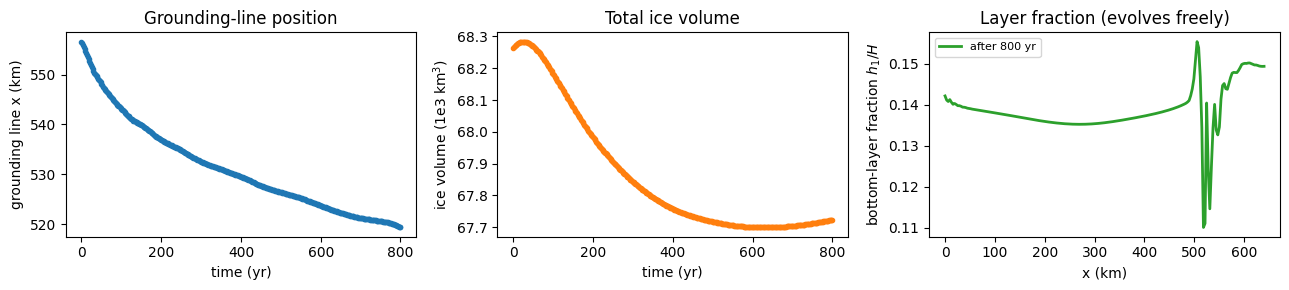

In [12]:
# bottom-layer thickness fraction along the centreline (it started uniform at 0.15)
frac_bot = np.array([h_layers[0].at([xi, Ly / 2]) / max(H.at([xi, Ly / 2]), 1e-6) for xi in xs])

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(13, 3.0))
a1.plot(hist[:, 0], hist[:, 1], "C0-o", ms=3)
a1.set_xlabel("time (yr)"); a1.set_ylabel("grounding line x (km)")
a1.set_title("Grounding-line position")
a2.plot(hist[:, 0], hist[:, 3], "C1-o", ms=3)
a2.set_xlabel("time (yr)"); a2.set_ylabel("ice volume (1e3 km$^3$)")
a2.set_title("Total ice volume")
a3.plot(xs / 1e3, frac_bot, "C2-", lw=2, label=f"after {SPINUP_YEARS:.0f} yr")
a3.set_xlabel("x (km)"); a3.set_ylabel(r"bottom-layer fraction $h_1/H$")
a3.set_title("Layer fraction (evolves freely)"); a3.legend(fontsize=8)
fig.tight_layout();

## Steady-state velocity

Below is the surface speed on the **equilibrated** geometry after the spin-up. Compare with the pre-spin-up diagnostic snapshot further up: the grounded interior is no longer stagnant once the thickness has adjusted to balance.

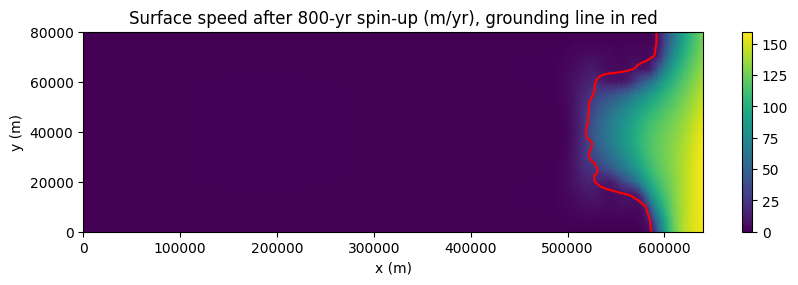

In [13]:
u_top = z.subfunctions[3]                       # final (post-spin-up) top-layer velocity
speed = Function(Q, name="surface_speed").interpolate(sqrt(inner(u_top, u_top)))
haf = Function(Q).interpolate(H - max_value(Constant(0.0), -bed) * Constant(rho_W / rho_I))

fig, ax = plt.subplots(figsize=(10, 2.6))
tpc = firedrake.tripcolor(speed, axes=ax, cmap="viridis")
firedrake.tricontour(haf, levels=[0.0], axes=ax, colors="red")
ax.set_title(f"Surface speed after {SPINUP_YEARS:.0f}-yr spin-up (m/yr), grounding line in red")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
fig.colorbar(tpc, ax=ax);

## Vertical shear: top/bottom speed ratio

The ratio $|u_{\rm top}|/|u_{\rm bot}|$ of surface (top, $n=1.8$) to basal
(bottom, $n=4$ temperate) layer speed — where the column departs from plug flow.
It is $\approx 1$ wherever the ice moves as a plug (most of MISMIP+); values
$>1$ mark where the soft temperate base concentrates vertical shear (largest
where the flow accelerates toward the grounding line). It is set to 1 in the
near-stagnant interior ($|u_{\rm bot}| < 1$ m/yr), where the ratio is ill-defined.


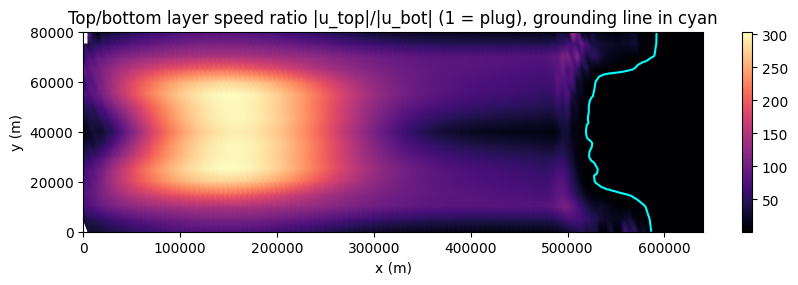

In [16]:
# Top/bottom layer speed ratio = vertical-shear structure (1 = plug flow).
u_top, u_bot = z.subfunctions[3], z.subfunctions[0]
spd_top, spd_bot = sqrt(inner(u_top, u_top)), sqrt(inner(u_bot, u_bot))
ratio = Function(Q, name="speed_ratio").interpolate(
spd_top / spd_bot)
haf = Function(Q).interpolate(H - max_value(Constant(0.0), -bed) * Constant(rho_W / rho_I))

fig, ax = plt.subplots(figsize=(10, 2.6))
tpc = firedrake.tripcolor(ratio, axes=ax, cmap="magma")
firedrake.tricontour(haf, levels=[0.0], axes=ax, colors="cyan",vmin=0,vmax=2)
ax.set_title("Top/bottom layer speed ratio |u_top|/|u_bot| (1 = plug), grounding line in cyan")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
fig.colorbar(tpc, ax=ax);


## Notes
**Composite flow law.** The physical composite rheology (soft $n=4$ temperate base, stiff $n=1.8$ top) is set per layer. The variational regularised-Coulomb residual has a well-conditioned stress block and the $n$, $m$ continuation handles the flow-law nonlinearity. They remain available for minimization-form work and for prognostic runs where $h\to0$.

**Steady state and shelf size.** The diagnostic solve is a snapshot on the *prescribed* thickness (its grounded interior is nearly stagnant). The **prognostic spin-up** evolves the thickness toward equilibrium. With the reduced accumulation ($a = 0.05$) the grounding line retreats from ~557 km to **~520 km** over `SPINUP_YEARS = 800` (`dt = 2` yr), giving a larger floating shelf than the full-accumulation case (which sits near 539 km). A standalone version with the optional Ice1r sub-shelf-melt response is in
`mismip_plus_spinup.py`.